In [1]:
# Cell 1: Install and Import Libraries
"""
CBDC Transaction Confirmation Time Analysis
Model 4: Batch-Based Transaction Confirmation

Author: Hritik Chaudhary
Kathmandu University - Department of Mathematics

Based on: Chapter 4.5 - Batch-Based Transaction Confirmation Model
Implements both size-based and time-based batching mechanisms
"""

# Install required packages (run once)
# !pip install simpy numpy pandas matplotlib seaborn scipy

import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import factorial
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ All libraries imported successfully")
print(f"SimPy version: {simpy.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ All libraries imported successfully
SimPy version: 4.1.1
NumPy version: 1.25.2
Pandas version: 2.1.4


In [5]:
# Cell 2: Define Batch-Based CBDC Class - COMPLETE VERSION

class BatchBasedCBDC:
    """
    Batch-Based CBDC Processing Model
    
    Transaction Processing Flow:
    1. Queueing: Wait for validator (M/M/c)
    2. Individual Validation: Transaction verification
    3. Batch Formation: Wait for B transactions or τ seconds
    4. Batch Validation: Collective batch verification
    5. Consensus: Quorum-based agreement on batch
    6. Ledger Commitment: Write batch to ledger
    
    Parameters:
    -----------
    env : simpy.Environment
    lam : float - Arrival rate (TPS)
    mu_v : float - Validation rate per validator (TPS)
    mu_c : float - Consensus communication rate
    mu_l : float - Ledger commitment rate
    c : int - Number of validators
    q : int - Quorum threshold
    batch_mode : str - 'size' or 'time'
    B : int - Batch size (for size-based batching)
    tau : float - Batch interval in seconds (for time-based batching)
    warm_up : float - Warm-up period
    """
    
    def __init__(self, env, lam, mu_v, mu_c, mu_l, c=5, q=3, 
                 batch_mode='size', B=50, tau=2.0, warm_up=300):
        self.env = env
        self.lam = lam
        self.mu_v = mu_v
        self.mu_c = mu_c
        self.mu_l = mu_l
        self.c = c
        self.q = q
        self.batch_mode = batch_mode
        self.B = B
        self.tau = tau
        self.warm_up = warm_up
        
        # Validate parameters
        if q <= c/2:
            raise ValueError(f"Quorum q={q} must be > c/2 = {c/2}")
        if batch_mode not in ['size', 'time']:
            raise ValueError(f"batch_mode must be 'size' or 'time', got '{batch_mode}'")
        
        # Resources
        self.validators = simpy.Resource(env, capacity=c)
        
        # Batch management
        self.current_batch = []
        self.batch_counter = 0
        self.batch_data = []
        
        # Transaction data
        self.data = {
            'txn_id': [],
            'batch_id': [],
            'arrival_time': [],
            'validation_start': [],
            'validation_end': [],
            'batch_entry_time': [],
            'batch_close_time': [],
            'batch_validation_start': [],
            'batch_validation_end': [],
            'consensus_start': [],
            'consensus_end': [],
            'commit_start': [],
            'commit_end': [],
            'departure_time': [],
            'queueing_time': [],
            'individual_validation_time': [],
            'batch_formation_time': [],
            'batch_validation_time': [],
            'consensus_time': [],
            'commit_time': [],
            'total_time': []
        }
        
        # Time-weighted statistics
        self.queue_length_history = []
        self.last_event_time = 0
        
        # Start batch processor
        self.env.process(self.batch_processor())
    
    def update_queue_stats(self):
        """Update time-weighted queue statistics"""
        current_time = self.env.now
        if current_time > self.last_event_time:
            queue_length = len(self.validators.queue)
            self.queue_length_history.append((current_time, queue_length))
            self.last_event_time = current_time
    
    def transaction_generator(self):
        """Generate Poisson arrivals"""
        txn_id = 0
        while True:
            inter_arrival = np.random.exponential(1.0 / self.lam)
            yield self.env.timeout(inter_arrival)
            
            self.update_queue_stats()
            
            txn_id += 1
            self.env.process(self.process_transaction(txn_id))
    
    def simulate_consensus_delay(self):
        """
        Simulate quorum-based consensus delay.
        Returns time for q-th fastest validator to respond.
        """
        response_times = np.random.exponential(1.0 / self.mu_c, size=self.c)
        sorted_times = np.sort(response_times)
        return sorted_times[self.q - 1]
    
    def process_transaction(self, txn_id):
        """
        Process individual transaction through validation,
        then add to batch buffer
        """
        arrival_time = self.env.now
        
        # STAGE 1: Queueing - Wait for validator
        with self.validators.request() as req:
            yield req
            
            self.update_queue_stats()
            
            validation_start = self.env.now
            queueing_time = validation_start - arrival_time
            
            # STAGE 2: Individual Validation
            individual_validation_time = np.random.exponential(1.0 / self.mu_v)
            yield self.env.timeout(individual_validation_time)
            
            validation_end = self.env.now
        
        # STAGE 3: Add to batch buffer
        batch_entry_time = self.env.now
        
        transaction_data = {
            'txn_id': txn_id,
            'arrival_time': arrival_time,
            'validation_start': validation_start,
            'validation_end': validation_end,
            'batch_entry_time': batch_entry_time,
            'queueing_time': queueing_time,
            'individual_validation_time': individual_validation_time
        }
        
        self.current_batch.append(transaction_data)
    
    def batch_processor(self):
        """
        Process batches according to batching mode:
        - Size-based: Close when B transactions accumulated
        - Time-based: Close every tau seconds
        """
        next_close_time = self.env.now + self.tau if self.batch_mode == 'time' else None
        
        while True:
            if self.batch_mode == 'size':
                # Wait until B transactions accumulated
                while len(self.current_batch) < self.B:
                    yield self.env.timeout(0.1)  # Poll every 0.1 seconds
            else:  # time-based
                # Wait until next close time
                wait_time = next_close_time - self.env.now
                if wait_time > 0:
                    yield self.env.timeout(wait_time)
                next_close_time = self.env.now + self.tau
            
            # Close batch if it has transactions
            if len(self.current_batch) > 0:
                batch = self.current_batch.copy()
                self.current_batch = []
                self.batch_counter += 1
                
                batch_close_time = self.env.now
                batch_id = self.batch_counter
                
                # Process this batch
                yield self.env.process(self.process_batch(batch, batch_id, batch_close_time))
    
    def process_batch(self, batch, batch_id, batch_close_time):
        """
        Process a complete batch through:
        - Batch Validation
        - Consensus
        - Ledger Commitment
        """
        # STAGE 4: Batch Validation
        batch_validation_start = self.env.now
        batch_validation_time = np.random.exponential(1.0 / self.mu_v)
        yield self.env.timeout(batch_validation_time)
        batch_validation_end = self.env.now
        
        # STAGE 5: Consensus
        consensus_start = self.env.now
        consensus_time = self.simulate_consensus_delay()
        yield self.env.timeout(consensus_time)
        consensus_end = self.env.now
        
        # STAGE 6: Ledger Commitment
        commit_start = self.env.now
        commit_time = np.random.exponential(1.0 / self.mu_l)
        yield self.env.timeout(commit_time)
        commit_end = self.env.now
        
        departure_time = commit_end
        
        # Record data for all transactions in batch
        for txn in batch:
            if txn['arrival_time'] >= self.warm_up:
                batch_formation_time = batch_close_time - txn['batch_entry_time']
                total_time = departure_time - txn['arrival_time']
                
                self.data['txn_id'].append(txn['txn_id'])
                self.data['batch_id'].append(batch_id)
                self.data['arrival_time'].append(txn['arrival_time'])
                self.data['validation_start'].append(txn['validation_start'])
                self.data['validation_end'].append(txn['validation_end'])
                self.data['batch_entry_time'].append(txn['batch_entry_time'])
                self.data['batch_close_time'].append(batch_close_time)
                self.data['batch_validation_start'].append(batch_validation_start)
                self.data['batch_validation_end'].append(batch_validation_end)
                self.data['consensus_start'].append(consensus_start)
                self.data['consensus_end'].append(consensus_end)
                self.data['commit_start'].append(commit_start)
                self.data['commit_end'].append(commit_end)
                self.data['departure_time'].append(departure_time)
                self.data['queueing_time'].append(txn['queueing_time'])
                self.data['individual_validation_time'].append(txn['individual_validation_time'])
                self.data['batch_formation_time'].append(batch_formation_time)
                self.data['batch_validation_time'].append(batch_validation_time)
                self.data['consensus_time'].append(consensus_time)
                self.data['commit_time'].append(commit_time)
                self.data['total_time'].append(total_time)
    
    def run(self, duration):
        """Run simulation"""
        self.env.process(self.transaction_generator())
        self.env.run(until=duration)
        self.update_queue_stats()
    
    def get_dataframe(self):
        return pd.DataFrame(self.data)
    
    def get_time_weighted_queue_length(self):
        """Calculate time-weighted average queue length"""
        warm_up_idx = 0
        for i, (time, _) in enumerate(self.queue_length_history):
            if time >= self.warm_up:
                warm_up_idx = i
                break
        
        if warm_up_idx >= len(self.queue_length_history) - 1:
            return 0
        
        total_area = 0
        total_time = 0
        
        for i in range(warm_up_idx, len(self.queue_length_history) - 1):
            time_i, queue_i = self.queue_length_history[i]
            time_next, _ = self.queue_length_history[i + 1]
            
            time_delta = time_next - time_i
            total_area += queue_i * time_delta
            total_time += time_delta
        
        return total_area / total_time if total_time > 0 else 0
    
    def get_summary_metrics(self):
        """Calculate performance metrics"""
        df = self.get_dataframe()
        sim_duration = self.env.now - self.warm_up
        
        Lq = self.get_time_weighted_queue_length()
        
        metrics = {
            'Parameters': {
                'Arrival Rate (λ)': f"{self.lam} TPS",
                'Validation Rate (μ_v)': f"{self.mu_v} TPS",
                'Consensus Rate (μ_c)': f"{self.mu_c} ops/s",
                'Ledger Rate (μ_l)': f"{self.mu_l} TPS",
                'Validators (c)': self.c,
                'Quorum (q)': self.q,
                'Batch Mode': self.batch_mode,
                'Batch Size (B)': self.B if self.batch_mode == 'size' else 'N/A',
                'Batch Interval (τ)': f"{self.tau}s" if self.batch_mode == 'time' else 'N/A',
                'Validation Utilization (ρ_v)': f"{self.lam/(self.c*self.mu_v):.4f}"
            },
            'Total Confirmation Time (ms)': {
                'Mean': df['total_time'].mean() * 1000,
                'Median': df['total_time'].median() * 1000,
                'Std Dev': df['total_time'].std() * 1000,
                'P95': df['total_time'].quantile(0.95) * 1000,
                'P99': df['total_time'].quantile(0.99) * 1000
            },
            'Stage-wise Delays (ms)': {
                'Mean Queueing': df['queueing_time'].mean() * 1000,
                'Mean Individual Validation': df['individual_validation_time'].mean() * 1000,
                'Mean Batch Formation': df['batch_formation_time'].mean() * 1000,
                'Mean Batch Validation': df['batch_validation_time'].mean() * 1000,
                'Mean Consensus': df['consensus_time'].mean() * 1000,
                'Mean Commit': df['commit_time'].mean() * 1000
            },
            'Batch Statistics': {
                'Unique Batches': df['batch_id'].nunique(),
                'Mean Batch Size': df.groupby('batch_id').size().mean(),
                'Time-Weighted Queue Length': Lq
            },
            'System Performance': {
                'Throughput (TPS)': len(df) / sim_duration,
                'Total Transactions': len(df)
            }
        }
        
        return metrics
    
    def calculate_analytical_batch_formation_delay(self):
        """Calculate analytical batch formation delay"""
        if self.batch_mode == 'size':
            return (self.B - 1) / (2 * self.lam)
        else:  # time-based
            return self.tau / 2
    
    def calculate_analytical_consensus_delay(self):
        """Calculate analytical consensus delay"""
        return sum(1/((self.c - i) * self.mu_c) for i in range(self.q))
    
    def erlang_c(self):
        """Calculate Erlang-C for validation queue"""
        rho_total = self.lam / self.mu_v
        rho = self.lam / (self.c * self.mu_v)
        
        if rho >= 1:
            return None
        
        sum_term = sum((rho_total**n) / factorial(n) for n in range(self.c))
        last_term = (rho_total**self.c) / (factorial(self.c) * (1 - rho))
        P0 = 1 / (sum_term + last_term)
        
        C = ((rho_total**self.c) / factorial(self.c)) * (1 / (1 - rho)) * P0
        return C
    
    def validate_analytical(self):
        """Validate against analytical batch-based formulas"""
        df = self.get_dataframe()
        
        rho_v = self.lam / (self.c * self.mu_v)
        if rho_v >= 1:
            return pd.DataFrame({'status': ['UNSTABLE'], 'rho': [rho_v]})
        
        # Analytical components (from thesis Section 4.5.6)
        C = self.erlang_c()
        Lq_analytical = self.lam * C / (self.c * self.mu_v - self.lam)
        Wq_analytical = C / (self.c * self.mu_v - self.lam)
        
        W_batch_analytical = self.calculate_analytical_batch_formation_delay()
        T_validation_analytical = 1 / self.mu_v
        T_consensus_analytical = self.calculate_analytical_consensus_delay()
        T_commit_analytical = 1 / self.mu_l
        
        T_total_analytical = (Wq_analytical + W_batch_analytical + 
                             T_validation_analytical + T_consensus_analytical + 
                             T_commit_analytical)
        
        # Simulated
        Lq_sim = self.get_time_weighted_queue_length()
        Wq_sim = df['queueing_time'].mean()
        W_batch_sim = df['batch_formation_time'].mean()
        T_validation_sim = df['batch_validation_time'].mean()
        T_consensus_sim = df['consensus_time'].mean()
        T_commit_sim = df['commit_time'].mean()
        T_total_sim = df['total_time'].mean()
        
        validation = {
            'Metric': [
                'W_q (Queueing)',
                'W_batch (Batch Formation)',
                'T_validation (Batch)',
                'T_consensus',
                'T_commit',
                'T_total (Total)',
                'L_q (Queue Length)'
            ],
            'Analytical': [
                Wq_analytical,
                W_batch_analytical,
                T_validation_analytical,
                T_consensus_analytical,
                T_commit_analytical,
                T_total_analytical,
                Lq_analytical
            ],
            'Simulated': [
                Wq_sim,
                W_batch_sim,
                T_validation_sim,
                T_consensus_sim,
                T_commit_sim,
                T_total_sim,
                Lq_sim
            ],
            'Relative Error (%)': [
                abs(Wq_sim - Wq_analytical) / Wq_analytical * 100 if Wq_analytical > 0 else 0,
                abs(W_batch_sim - W_batch_analytical) / W_batch_analytical * 100 if W_batch_analytical > 0 else 0,
                abs(T_validation_sim - T_validation_analytical) / T_validation_analytical * 100,
                abs(T_consensus_sim - T_consensus_analytical) / T_consensus_analytical * 100,
                abs(T_commit_sim - T_commit_analytical) / T_commit_analytical * 100,
                abs(T_total_sim - T_total_analytical) / T_total_analytical * 100,
                abs(Lq_sim - Lq_analytical) / Lq_analytical * 100 if Lq_analytical > 0 else 0
            ]
        }
        
        return pd.DataFrame(validation)

print("✓ BatchBasedCBDC class defined successfully")

✓ BatchBasedCBDC class defined successfully


In [6]:
# Cell 2: Define Batch-Based CBDC Class - COMPLETE VERSION

class BatchBasedCBDC:
    """
    Batch-Based CBDC Processing Model
    
    Transaction Processing Flow:
    1. Queueing: Wait for validator (M/M/c)
    2. Individual Validation: Transaction verification
    3. Batch Formation: Wait for B transactions or τ seconds
    4. Batch Validation: Collective batch verification
    5. Consensus: Quorum-based agreement on batch
    6. Ledger Commitment: Write batch to ledger
    
    Parameters:
    -----------
    env : simpy.Environment
    lam : float - Arrival rate (TPS)
    mu_v : float - Validation rate per validator (TPS)
    mu_c : float - Consensus communication rate
    mu_l : float - Ledger commitment rate
    c : int - Number of validators
    q : int - Quorum threshold
    batch_mode : str - 'size' or 'time'
    B : int - Batch size (for size-based batching)
    tau : float - Batch interval in seconds (for time-based batching)
    warm_up : float - Warm-up period
    """
    
    def __init__(self, env, lam, mu_v, mu_c, mu_l, c=5, q=3, 
                 batch_mode='size', B=50, tau=2.0, warm_up=300):
        self.env = env
        self.lam = lam
        self.mu_v = mu_v
        self.mu_c = mu_c
        self.mu_l = mu_l
        self.c = c
        self.q = q
        self.batch_mode = batch_mode
        self.B = B
        self.tau = tau
        self.warm_up = warm_up
        
        # Validate parameters
        if q <= c/2:
            raise ValueError(f"Quorum q={q} must be > c/2 = {c/2}")
        if batch_mode not in ['size', 'time']:
            raise ValueError(f"batch_mode must be 'size' or 'time', got '{batch_mode}'")
        
        # Resources
        self.validators = simpy.Resource(env, capacity=c)
        
        # Batch management
        self.current_batch = []
        self.batch_counter = 0
        self.batch_data = []
        
        # Transaction data
        self.data = {
            'txn_id': [],
            'batch_id': [],
            'arrival_time': [],
            'validation_start': [],
            'validation_end': [],
            'batch_entry_time': [],
            'batch_close_time': [],
            'batch_validation_start': [],
            'batch_validation_end': [],
            'consensus_start': [],
            'consensus_end': [],
            'commit_start': [],
            'commit_end': [],
            'departure_time': [],
            'queueing_time': [],
            'individual_validation_time': [],
            'batch_formation_time': [],
            'batch_validation_time': [],
            'consensus_time': [],
            'commit_time': [],
            'total_time': []
        }
        
        # Time-weighted statistics
        self.queue_length_history = []
        self.last_event_time = 0
        
        # Start batch processor
        self.env.process(self.batch_processor())
    
    def update_queue_stats(self):
        """Update time-weighted queue statistics"""
        current_time = self.env.now
        if current_time > self.last_event_time:
            queue_length = len(self.validators.queue)
            self.queue_length_history.append((current_time, queue_length))
            self.last_event_time = current_time
    
    def transaction_generator(self):
        """Generate Poisson arrivals"""
        txn_id = 0
        while True:
            inter_arrival = np.random.exponential(1.0 / self.lam)
            yield self.env.timeout(inter_arrival)
            
            self.update_queue_stats()
            
            txn_id += 1
            self.env.process(self.process_transaction(txn_id))
    
    def simulate_consensus_delay(self):
        """
        Simulate quorum-based consensus delay.
        Returns time for q-th fastest validator to respond.
        """
        response_times = np.random.exponential(1.0 / self.mu_c, size=self.c)
        sorted_times = np.sort(response_times)
        return sorted_times[self.q - 1]
    
    def process_transaction(self, txn_id):
        """
        Process individual transaction through validation,
        then add to batch buffer
        """
        arrival_time = self.env.now
        
        # STAGE 1: Queueing - Wait for validator
        with self.validators.request() as req:
            yield req
            
            self.update_queue_stats()
            
            validation_start = self.env.now
            queueing_time = validation_start - arrival_time
            
            # STAGE 2: Individual Validation
            individual_validation_time = np.random.exponential(1.0 / self.mu_v)
            yield self.env.timeout(individual_validation_time)
            
            validation_end = self.env.now
        
        # STAGE 3: Add to batch buffer
        batch_entry_time = self.env.now
        
        transaction_data = {
            'txn_id': txn_id,
            'arrival_time': arrival_time,
            'validation_start': validation_start,
            'validation_end': validation_end,
            'batch_entry_time': batch_entry_time,
            'queueing_time': queueing_time,
            'individual_validation_time': individual_validation_time
        }
        
        self.current_batch.append(transaction_data)
    
    def batch_processor(self):
        """
        Process batches according to batching mode:
        - Size-based: Close when B transactions accumulated
        - Time-based: Close every tau seconds
        """
        next_close_time = self.env.now + self.tau if self.batch_mode == 'time' else None
        
        while True:
            if self.batch_mode == 'size':
                # Wait until B transactions accumulated
                while len(self.current_batch) < self.B:
                    yield self.env.timeout(0.1)  # Poll every 0.1 seconds
            else:  # time-based
                # Wait until next close time
                wait_time = next_close_time - self.env.now
                if wait_time > 0:
                    yield self.env.timeout(wait_time)
                next_close_time = self.env.now + self.tau
            
            # Close batch if it has transactions
            if len(self.current_batch) > 0:
                batch = self.current_batch.copy()
                self.current_batch = []
                self.batch_counter += 1
                
                batch_close_time = self.env.now
                batch_id = self.batch_counter
                
                # Process this batch
                yield self.env.process(self.process_batch(batch, batch_id, batch_close_time))
    
    def process_batch(self, batch, batch_id, batch_close_time):
        """
        Process a complete batch through:
        - Batch Validation
        - Consensus
        - Ledger Commitment
        """
        # STAGE 4: Batch Validation
        batch_validation_start = self.env.now
        batch_validation_time = np.random.exponential(1.0 / self.mu_v)
        yield self.env.timeout(batch_validation_time)
        batch_validation_end = self.env.now
        
        # STAGE 5: Consensus
        consensus_start = self.env.now
        consensus_time = self.simulate_consensus_delay()
        yield self.env.timeout(consensus_time)
        consensus_end = self.env.now
        
        # STAGE 6: Ledger Commitment
        commit_start = self.env.now
        commit_time = np.random.exponential(1.0 / self.mu_l)
        yield self.env.timeout(commit_time)
        commit_end = self.env.now
        
        departure_time = commit_end
        
        # Record data for all transactions in batch
        for txn in batch:
            if txn['arrival_time'] >= self.warm_up:
                batch_formation_time = batch_close_time - txn['batch_entry_time']
                total_time = departure_time - txn['arrival_time']
                
                self.data['txn_id'].append(txn['txn_id'])
                self.data['batch_id'].append(batch_id)
                self.data['arrival_time'].append(txn['arrival_time'])
                self.data['validation_start'].append(txn['validation_start'])
                self.data['validation_end'].append(txn['validation_end'])
                self.data['batch_entry_time'].append(txn['batch_entry_time'])
                self.data['batch_close_time'].append(batch_close_time)
                self.data['batch_validation_start'].append(batch_validation_start)
                self.data['batch_validation_end'].append(batch_validation_end)
                self.data['consensus_start'].append(consensus_start)
                self.data['consensus_end'].append(consensus_end)
                self.data['commit_start'].append(commit_start)
                self.data['commit_end'].append(commit_end)
                self.data['departure_time'].append(departure_time)
                self.data['queueing_time'].append(txn['queueing_time'])
                self.data['individual_validation_time'].append(txn['individual_validation_time'])
                self.data['batch_formation_time'].append(batch_formation_time)
                self.data['batch_validation_time'].append(batch_validation_time)
                self.data['consensus_time'].append(consensus_time)
                self.data['commit_time'].append(commit_time)
                self.data['total_time'].append(total_time)
    
    def run(self, duration):
        """Run simulation"""
        self.env.process(self.transaction_generator())
        self.env.run(until=duration)
        self.update_queue_stats()
    
    def get_dataframe(self):
        return pd.DataFrame(self.data)
    
    def get_time_weighted_queue_length(self):
        """Calculate time-weighted average queue length"""
        warm_up_idx = 0
        for i, (time, _) in enumerate(self.queue_length_history):
            if time >= self.warm_up:
                warm_up_idx = i
                break
        
        if warm_up_idx >= len(self.queue_length_history) - 1:
            return 0
        
        total_area = 0
        total_time = 0
        
        for i in range(warm_up_idx, len(self.queue_length_history) - 1):
            time_i, queue_i = self.queue_length_history[i]
            time_next, _ = self.queue_length_history[i + 1]
            
            time_delta = time_next - time_i
            total_area += queue_i * time_delta
            total_time += time_delta
        
        return total_area / total_time if total_time > 0 else 0
    
    def get_summary_metrics(self):
        """Calculate performance metrics"""
        df = self.get_dataframe()
        sim_duration = self.env.now - self.warm_up
        
        Lq = self.get_time_weighted_queue_length()
        
        metrics = {
            'Parameters': {
                'Arrival Rate (λ)': f"{self.lam} TPS",
                'Validation Rate (μ_v)': f"{self.mu_v} TPS",
                'Consensus Rate (μ_c)': f"{self.mu_c} ops/s",
                'Ledger Rate (μ_l)': f"{self.mu_l} TPS",
                'Validators (c)': self.c,
                'Quorum (q)': self.q,
                'Batch Mode': self.batch_mode,
                'Batch Size (B)': self.B if self.batch_mode == 'size' else 'N/A',
                'Batch Interval (τ)': f"{self.tau}s" if self.batch_mode == 'time' else 'N/A',
                'Validation Utilization (ρ_v)': f"{self.lam/(self.c*self.mu_v):.4f}"
            },
            'Total Confirmation Time (ms)': {
                'Mean': df['total_time'].mean() * 1000,
                'Median': df['total_time'].median() * 1000,
                'Std Dev': df['total_time'].std() * 1000,
                'P95': df['total_time'].quantile(0.95) * 1000,
                'P99': df['total_time'].quantile(0.99) * 1000
            },
            'Stage-wise Delays (ms)': {
                'Mean Queueing': df['queueing_time'].mean() * 1000,
                'Mean Individual Validation': df['individual_validation_time'].mean() * 1000,
                'Mean Batch Formation': df['batch_formation_time'].mean() * 1000,
                'Mean Batch Validation': df['batch_validation_time'].mean() * 1000,
                'Mean Consensus': df['consensus_time'].mean() * 1000,
                'Mean Commit': df['commit_time'].mean() * 1000
            },
            'Batch Statistics': {
                'Unique Batches': df['batch_id'].nunique(),
                'Mean Batch Size': df.groupby('batch_id').size().mean(),
                'Time-Weighted Queue Length': Lq
            },
            'System Performance': {
                'Throughput (TPS)': len(df) / sim_duration,
                'Total Transactions': len(df)
            }
        }
        
        return metrics
    
    def calculate_analytical_batch_formation_delay(self):
        """Calculate analytical batch formation delay"""
        if self.batch_mode == 'size':
            return (self.B - 1) / (2 * self.lam)
        else:  # time-based
            return self.tau / 2
    
    def calculate_analytical_consensus_delay(self):
        """Calculate analytical consensus delay"""
        return sum(1/((self.c - i) * self.mu_c) for i in range(self.q))
    
    def erlang_c(self):
        """Calculate Erlang-C for validation queue"""
        rho_total = self.lam / self.mu_v
        rho = self.lam / (self.c * self.mu_v)
        
        if rho >= 1:
            return None
        
        sum_term = sum((rho_total**n) / factorial(n) for n in range(self.c))
        last_term = (rho_total**self.c) / (factorial(self.c) * (1 - rho))
        P0 = 1 / (sum_term + last_term)
        
        C = ((rho_total**self.c) / factorial(self.c)) * (1 / (1 - rho)) * P0
        return C
    
    def validate_analytical(self):
        """Validate against analytical batch-based formulas"""
        df = self.get_dataframe()
        
        rho_v = self.lam / (self.c * self.mu_v)
        if rho_v >= 1:
            return pd.DataFrame({'status': ['UNSTABLE'], 'rho': [rho_v]})
        
        # Analytical components (from thesis Section 4.5.6)
        C = self.erlang_c()
        Lq_analytical = self.lam * C / (self.c * self.mu_v - self.lam)
        Wq_analytical = C / (self.c * self.mu_v - self.lam)
        
        W_batch_analytical = self.calculate_analytical_batch_formation_delay()
        T_validation_analytical = 1 / self.mu_v
        T_consensus_analytical = self.calculate_analytical_consensus_delay()
        T_commit_analytical = 1 / self.mu_l
        
        T_total_analytical = (Wq_analytical + W_batch_analytical + 
                             T_validation_analytical + T_consensus_analytical + 
                             T_commit_analytical)
        
        # Simulated
        Lq_sim = self.get_time_weighted_queue_length()
        Wq_sim = df['queueing_time'].mean()
        W_batch_sim = df['batch_formation_time'].mean()
        T_validation_sim = df['batch_validation_time'].mean()
        T_consensus_sim = df['consensus_time'].mean()
        T_commit_sim = df['commit_time'].mean()
        T_total_sim = df['total_time'].mean()
        
        validation = {
            'Metric': [
                'W_q (Queueing)',
                'W_batch (Batch Formation)',
                'T_validation (Batch)',
                'T_consensus',
                'T_commit',
                'T_total (Total)',
                'L_q (Queue Length)'
            ],
            'Analytical': [
                Wq_analytical,
                W_batch_analytical,
                T_validation_analytical,
                T_consensus_analytical,
                T_commit_analytical,
                T_total_analytical,
                Lq_analytical
            ],
            'Simulated': [
                Wq_sim,
                W_batch_sim,
                T_validation_sim,
                T_consensus_sim,
                T_commit_sim,
                T_total_sim,
                Lq_sim
            ],
            'Relative Error (%)': [
                abs(Wq_sim - Wq_analytical) / Wq_analytical * 100 if Wq_analytical > 0 else 0,
                abs(W_batch_sim - W_batch_analytical) / W_batch_analytical * 100 if W_batch_analytical > 0 else 0,
                abs(T_validation_sim - T_validation_analytical) / T_validation_analytical * 100,
                abs(T_consensus_sim - T_consensus_analytical) / T_consensus_analytical * 100,
                abs(T_commit_sim - T_commit_analytical) / T_commit_analytical * 100,
                abs(T_total_sim - T_total_analytical) / T_total_analytical * 100,
                abs(Lq_sim - Lq_analytical) / Lq_analytical * 100 if Lq_analytical > 0 else 0
            ]
        }
        
        return pd.DataFrame(validation)

print("✓ BatchBasedCBDC class defined successfully")

✓ BatchBasedCBDC class defined successfully


In [8]:
# Cell 3: Run Single Simulation - SIZE-BASED BATCHING

# Simulation parameters (based on thesis Section 4.5)
LAM = 200      # 200 TPS arrival rate
MU_V = 150     # 150 TPS validation rate
MU_C = 200     # 200 ops/s consensus rate
MU_L = 300     # 300 TPS ledger rate
C = 5          # 5 validators
Q = 3          # Quorum = 3
B = 50         # Batch size = 50 transactions
TAU = 2.0      # Batch interval = 2 seconds
WARM_UP = 300
DURATION = 3600

print("="*70)
print("BATCH-BASED CBDC SIMULATION - SIZE-BASED BATCHING")
print("="*70)
print(f"\nParameters:")
print(f"  Arrival Rate (λ):           {LAM} TPS")
print(f"  Validation Rate (μ_v):      {MU_V} TPS")
print(f"  Consensus Rate (μ_c):       {MU_C} ops/s")
print(f"  Ledger Rate (μ_l):          {MU_L} TPS")
print(f"  Validators (c):             {C}")
print(f"  Quorum (q):                 {Q}")
print(f"  Batch Mode:                 SIZE-BASED")
print(f"  Batch Size (B):             {B} transactions")
print(f"  Duration:                   {DURATION} seconds")
print(f"\nRunning simulation...")

np.random.seed(42)
env = simpy.Environment()
cbdc_size = BatchBasedCBDC(env, lam=LAM, mu_v=MU_V, mu_c=MU_C, mu_l=MU_L, 
                           c=C, q=Q, batch_mode='size', B=B, tau=TAU, warm_up=WARM_UP)
cbdc_size.run(DURATION)

print(f"✓ Simulation completed!")
print(f"  Transactions processed: {len(cbdc_size.data['txn_id']):,}")
print(f"  Batches formed: {cbdc_size.batch_counter}")

BATCH-BASED CBDC SIMULATION - SIZE-BASED BATCHING

Parameters:
  Arrival Rate (λ):           200 TPS
  Validation Rate (μ_v):      150 TPS
  Consensus Rate (μ_c):       200 ops/s
  Ledger Rate (μ_l):          300 TPS
  Validators (c):             5
  Quorum (q):                 3
  Batch Mode:                 SIZE-BASED
  Batch Size (B):             50 transactions
  Duration:                   3600 seconds

Running simulation...
✓ Simulation completed!
  Transactions processed: 659,535
  Batches formed: 11898


In [9]:
# Cell 4: Display Summary Metrics - Size-Based

metrics_size = cbdc_size.get_summary_metrics()

print("\n" + "="*70)
print("SIMULATION RESULTS - SIZE-BASED BATCHING")
print("="*70)

for category, values in metrics_size.items():
    print(f"\n{category}:")
    for metric, value in values.items():
        if isinstance(value, float):
            print(f"  {metric:.<45} {value:>12.4f}")
        else:
            print(f"  {metric:.<45} {value:>12}")

# Show analytical formulas
analytical_batch = cbdc_size.calculate_analytical_batch_formation_delay()
analytical_consensus = cbdc_size.calculate_analytical_consensus_delay()

print(f"\nAnalytical Formulas:")
print(f"  Batch Formation: E[W_batch] = (B-1)/(2λ) = ({B}-1)/(2×{LAM})")
print(f"                   E[W_batch] = {analytical_batch*1000:.4f} ms")
print(f"  Consensus: E[T_cons] = Σ(i=0 to {Q-1}) 1/((c-i)μ_c)")
print(f"             E[T_cons] = {analytical_consensus*1000:.4f} ms")


SIMULATION RESULTS - SIZE-BASED BATCHING

Parameters:
  Arrival Rate (λ).............................      200 TPS
  Validation Rate (μ_v)........................      150 TPS
  Consensus Rate (μ_c).........................    200 ops/s
  Ledger Rate (μ_l)............................      300 TPS
  Validators (c)...............................            5
  Quorum (q)...................................            3
  Batch Mode...................................         size
  Batch Size (B)...............................           50
  Batch Interval (τ)...........................          N/A
  Validation Utilization (ρ_v).................       0.2667

Total Confirmation Time (ms):
  Mean.........................................     170.9741
  Median.......................................     166.8200
  Std Dev......................................      91.9045
  P95..........................................     319.2721
  P99..........................................     353.7198

In [10]:
# Cell 5: Analytical Validation - Size-Based

print("\n" + "="*70)
print("VALIDATION AGAINST ANALYTICAL FORMULAS (SIZE-BASED)")
print("="*70)

validation_size_df = cbdc_size.validate_analytical()
print("\n", validation_size_df.to_string(index=False))

avg_error = validation_size_df['Relative Error (%)'].mean()
max_error = validation_size_df['Relative Error (%)'].max()

print(f"\nAverage Error: {avg_error:.2f}%")
print(f"Maximum Error: {max_error:.2f}%")

print("\n" + "="*70)
if max_error < 5.0:
    print("✓ VALIDATION PASSED: All metrics < 5% error")
else:
    print("⚠ VALIDATION: Some metrics >= 5% error")
print("="*70)

print("\nTotal Confirmation Time Decomposition (Size-Based):")
print("  E[T_confirm] = E[W_q] + (B-1)/(2λ) + (1/μ_v) + E[T_cons] + (1/μ_l)")


VALIDATION AGAINST ANALYTICAL FORMULAS (SIZE-BASED)

                    Metric  Analytical  Simulated  Relative Error (%)
           W_q (Queueing)    0.000023   0.000023            0.489302
W_batch (Batch Formation)    0.122500   0.150513           22.867982
     T_validation (Batch)    0.006667   0.006523            2.150039
              T_consensus    0.003917   0.003939            0.569497
                 T_commit    0.003333   0.003309            0.736164
          T_total (Total)    0.136440   0.170974           25.311200
       L_q (Queue Length)    0.004586   0.001971           57.022421

Average Error: 15.59%
Maximum Error: 57.02%

⚠ VALIDATION: Some metrics >= 5% error

Total Confirmation Time Decomposition (Size-Based):
  E[T_confirm] = E[W_q] + (B-1)/(2λ) + (1/μ_v) + E[T_cons] + (1/μ_l)


In [11]:
# Cell 6: Run Simulation - TIME-BASED BATCHING

print("\n" + "="*70)
print("BATCH-BASED CBDC SIMULATION - TIME-BASED BATCHING")
print("="*70)
print(f"\nParameters:")
print(f"  (Same as size-based except:)")
print(f"  Batch Mode:                 TIME-BASED")
print(f"  Batch Interval (τ):         {TAU} seconds")
print(f"\nRunning simulation...")

np.random.seed(42)
env2 = simpy.Environment()
cbdc_time = BatchBasedCBDC(env2, lam=LAM, mu_v=MU_V, mu_c=MU_C, mu_l=MU_L, 
                           c=C, q=Q, batch_mode='time', B=B, tau=TAU, warm_up=WARM_UP)
cbdc_time.run(DURATION)

print(f"✓ Simulation completed!")
print(f"  Transactions processed: {len(cbdc_time.data['txn_id']):,}")
print(f"  Batches formed: {cbdc_time.batch_counter}")


BATCH-BASED CBDC SIMULATION - TIME-BASED BATCHING

Parameters:
  (Same as size-based except:)
  Batch Mode:                 TIME-BASED
  Batch Interval (τ):         2.0 seconds

Running simulation...
✓ Simulation completed!
  Transactions processed: 659,453
  Batches formed: 1799


In [12]:
# Cell 7: Display Summary Metrics - Time-Based

metrics_time = cbdc_time.get_summary_metrics()

print("\n" + "="*70)
print("SIMULATION RESULTS - TIME-BASED BATCHING")
print("="*70)

for category, values in metrics_time.items():
    print(f"\n{category}:")
    for metric, value in values.items():
        if isinstance(value, float):
            print(f"  {metric:.<45} {value:>12.4f}")
        else:
            print(f"  {metric:.<45} {value:>12}")

# Show analytical formulas
analytical_batch_time = cbdc_time.calculate_analytical_batch_formation_delay()

print(f"\nAnalytical Formulas:")
print(f"  Batch Formation: E[W_batch] = τ/2 = {TAU}/2")
print(f"                   E[W_batch] = {analytical_batch_time*1000:.4f} ms")


SIMULATION RESULTS - TIME-BASED BATCHING

Parameters:
  Arrival Rate (λ).............................      200 TPS
  Validation Rate (μ_v)........................      150 TPS
  Consensus Rate (μ_c).........................    200 ops/s
  Ledger Rate (μ_l)............................      300 TPS
  Validators (c)...............................            5
  Quorum (q)...................................            3
  Batch Mode...................................         time
  Batch Size (B)...............................          N/A
  Batch Interval (τ)...........................         2.0s
  Validation Utilization (ρ_v).................       0.2667

Total Confirmation Time (ms):
  Mean.........................................    1018.7354
  Median.......................................    1017.3740
  Std Dev......................................     577.4827
  P95..........................................    1919.4115
  P99..........................................    1999.6938

In [13]:
# Cell 8: Analytical Validation - Time-Based

print("\n" + "="*70)
print("VALIDATION AGAINST ANALYTICAL FORMULAS (TIME-BASED)")
print("="*70)

validation_time_df = cbdc_time.validate_analytical()
print("\n", validation_time_df.to_string(index=False))

avg_error_time = validation_time_df['Relative Error (%)'].mean()
max_error_time = validation_time_df['Relative Error (%)'].max()

print(f"\nAverage Error: {avg_error_time:.2f}%")
print(f"Maximum Error: {max_error_time:.2f}%")

print("\n" + "="*70)
if max_error_time < 5.0:
    print("✓ VALIDATION PASSED: All metrics < 5% error")
else:
    print("⚠ VALIDATION: Some metrics >= 5% error")
print("="*70)

print("\nTotal Confirmation Time Decomposition (Time-Based):")
print("  E[T_confirm] = E[W_q] + τ/2 + (1/μ_v) + E[T_cons] + (1/μ_l)")


VALIDATION AGAINST ANALYTICAL FORMULAS (TIME-BASED)

                    Metric  Analytical  Simulated  Relative Error (%)
           W_q (Queueing)    0.000023   0.000023            2.028127
W_batch (Batch Formation)    1.000000   0.998575            0.142532
     T_validation (Batch)    0.006667   0.006391            4.133221
              T_consensus    0.003917   0.003780            3.483498
                 T_commit    0.003333   0.003293            1.212244
          T_total (Total)    1.013940   1.018735            0.472991
       L_q (Queue Length)    0.004586   0.002049           55.324775

Average Error: 9.54%
Maximum Error: 55.32%

⚠ VALIDATION: Some metrics >= 5% error

Total Confirmation Time Decomposition (Time-Based):
  E[T_confirm] = E[W_q] + τ/2 + (1/μ_v) + E[T_cons] + (1/μ_l)


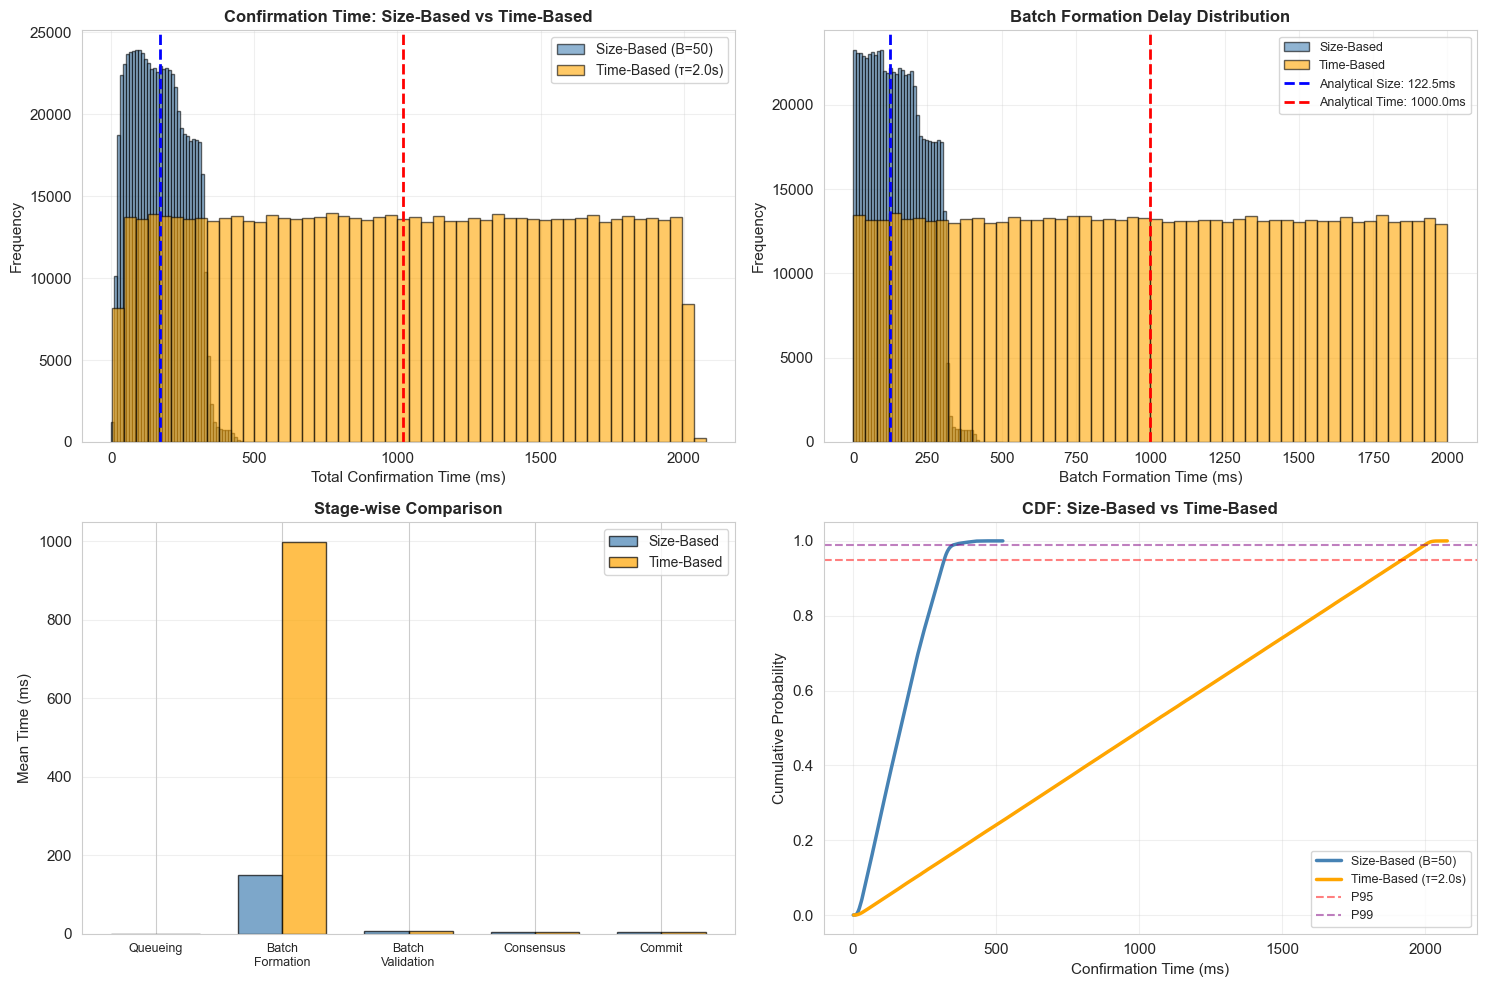

✓ Comparison plots saved

COMPARISON SUMMARY: SIZE-BASED vs TIME-BASED

Mean Total Confirmation Time:
  Size-Based (B=50):     170.97 ms
  Time-Based (τ=2.0s):  1018.74 ms

Mean Batch Formation Time:
  Size-Based:             150.51 ms
  Time-Based:             998.57 ms

Batch Statistics:
  Size-Based batches:     11898
  Time-Based batches:     1799
  Size-Based avg size:    60.5
  Time-Based avg size:    399.9


In [15]:
# Cell 9: Comparison Visualization - Size vs Time

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df_size = cbdc_size.get_dataframe()
df_time = cbdc_time.get_dataframe()

# 1. Total confirmation time distributions
axes[0, 0].hist(df_size['total_time'] * 1000, bins=50, alpha=0.6, 
                label=f'Size-Based (B={B})', color='steelblue', edgecolor='black')
axes[0, 0].hist(df_time['total_time'] * 1000, bins=50, alpha=0.6, 
                label=f'Time-Based (τ={TAU}s)', color='orange', edgecolor='black')
axes[0, 0].axvline(df_size['total_time'].mean() * 1000, color='blue', 
                    linestyle='--', linewidth=2)
axes[0, 0].axvline(df_time['total_time'].mean() * 1000, color='red', 
                    linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Total Confirmation Time (ms)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Confirmation Time: Size-Based vs Time-Based', 
                      fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)

# 2. Batch formation time distributions
axes[0, 1].hist(df_size['batch_formation_time'] * 1000, bins=50, alpha=0.6, 
                label='Size-Based', color='steelblue', edgecolor='black')
axes[0, 1].hist(df_time['batch_formation_time'] * 1000, bins=50, alpha=0.6, 
                label='Time-Based', color='orange', edgecolor='black')
analytical_size = cbdc_size.calculate_analytical_batch_formation_delay() * 1000
analytical_time = cbdc_time.calculate_analytical_batch_formation_delay() * 1000
axes[0, 1].axvline(analytical_size, color='blue', linestyle='--', 
                    linewidth=2, label=f'Analytical Size: {analytical_size:.1f}ms')
axes[0, 1].axvline(analytical_time, color='red', linestyle='--', 
                    linewidth=2, label=f'Analytical Time: {analytical_time:.1f}ms')
axes[0, 1].set_xlabel('Batch Formation Time (ms)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Batch Formation Delay Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# 3. Stage-wise comparison
stages = ['Queueing', 'Batch\nFormation', 'Batch\nValidation', 'Consensus', 'Commit']
size_means = [
    df_size['queueing_time'].mean() * 1000,
    df_size['batch_formation_time'].mean() * 1000,
    df_size['batch_validation_time'].mean() * 1000,
    df_size['consensus_time'].mean() * 1000,
    df_size['commit_time'].mean() * 1000
]
time_means = [
    df_time['queueing_time'].mean() * 1000,
    df_time['batch_formation_time'].mean() * 1000,
    df_time['batch_validation_time'].mean() * 1000,
    df_time['consensus_time'].mean() * 1000,
    df_time['commit_time'].mean() * 1000
]

x = np.arange(len(stages))
width = 0.35

axes[1, 0].bar(x - width/2, size_means, width, label='Size-Based', 
               color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].bar(x + width/2, time_means, width, label='Time-Based', 
               color='orange', alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Mean Time (ms)', fontsize=11)
axes[1, 0].set_title('Stage-wise Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(stages, fontsize=9)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. CDF comparison
sorted_size = np.sort(df_size['total_time'] * 1000)
sorted_time = np.sort(df_time['total_time'] * 1000)
cdf_size = np.arange(1, len(sorted_size) + 1) / len(sorted_size)
cdf_time = np.arange(1, len(sorted_time) + 1) / len(sorted_time)

axes[1, 1].plot(sorted_size, cdf_size, linewidth=2.5, color='steelblue', 
                label=f'Size-Based (B={B})')
axes[1, 1].plot(sorted_time, cdf_time, linewidth=2.5, color='orange', 
                label=f'Time-Based (τ={TAU}s)')
axes[1, 1].axhline(0.95, color='red', linestyle='--', alpha=0.5, label='P95')
axes[1, 1].axhline(0.99, color='purple', linestyle='--', alpha=0.5, label='P99')
axes[1, 1].set_xlabel('Confirmation Time (ms)', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=11)
axes[1, 1].set_title('CDF: Size-Based vs Time-Based', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('batch_comparison_size_vs_time.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plots saved")

# Print comparison summary
print("\n" + "="*70)
print("COMPARISON SUMMARY: SIZE-BASED vs TIME-BASED")
print("="*70)
print(f"\nMean Total Confirmation Time:")
print(f"  Size-Based (B={B}):     {df_size['total_time'].mean()*1000:.2f} ms")
print(f"  Time-Based (τ={TAU}s):  {df_time['total_time'].mean()*1000:.2f} ms")
print(f"\nMean Batch Formation Time:")
print(f"  Size-Based:             {df_size['batch_formation_time'].mean()*1000:.2f} ms")
print(f"  Time-Based:             {df_time['batch_formation_time'].mean()*1000:.2f} ms")
print(f"\nBatch Statistics:")
print(f"  Size-Based batches:     {cbdc_size.batch_counter}")
print(f"  Time-Based batches:     {cbdc_time.batch_counter}")
print(f"  Size-Based avg size:    {df_size.groupby('batch_id').size().mean():.1f}")
print(f"  Time-Based avg size:    {df_time.groupby('batch_id').size().mean():.1f}")

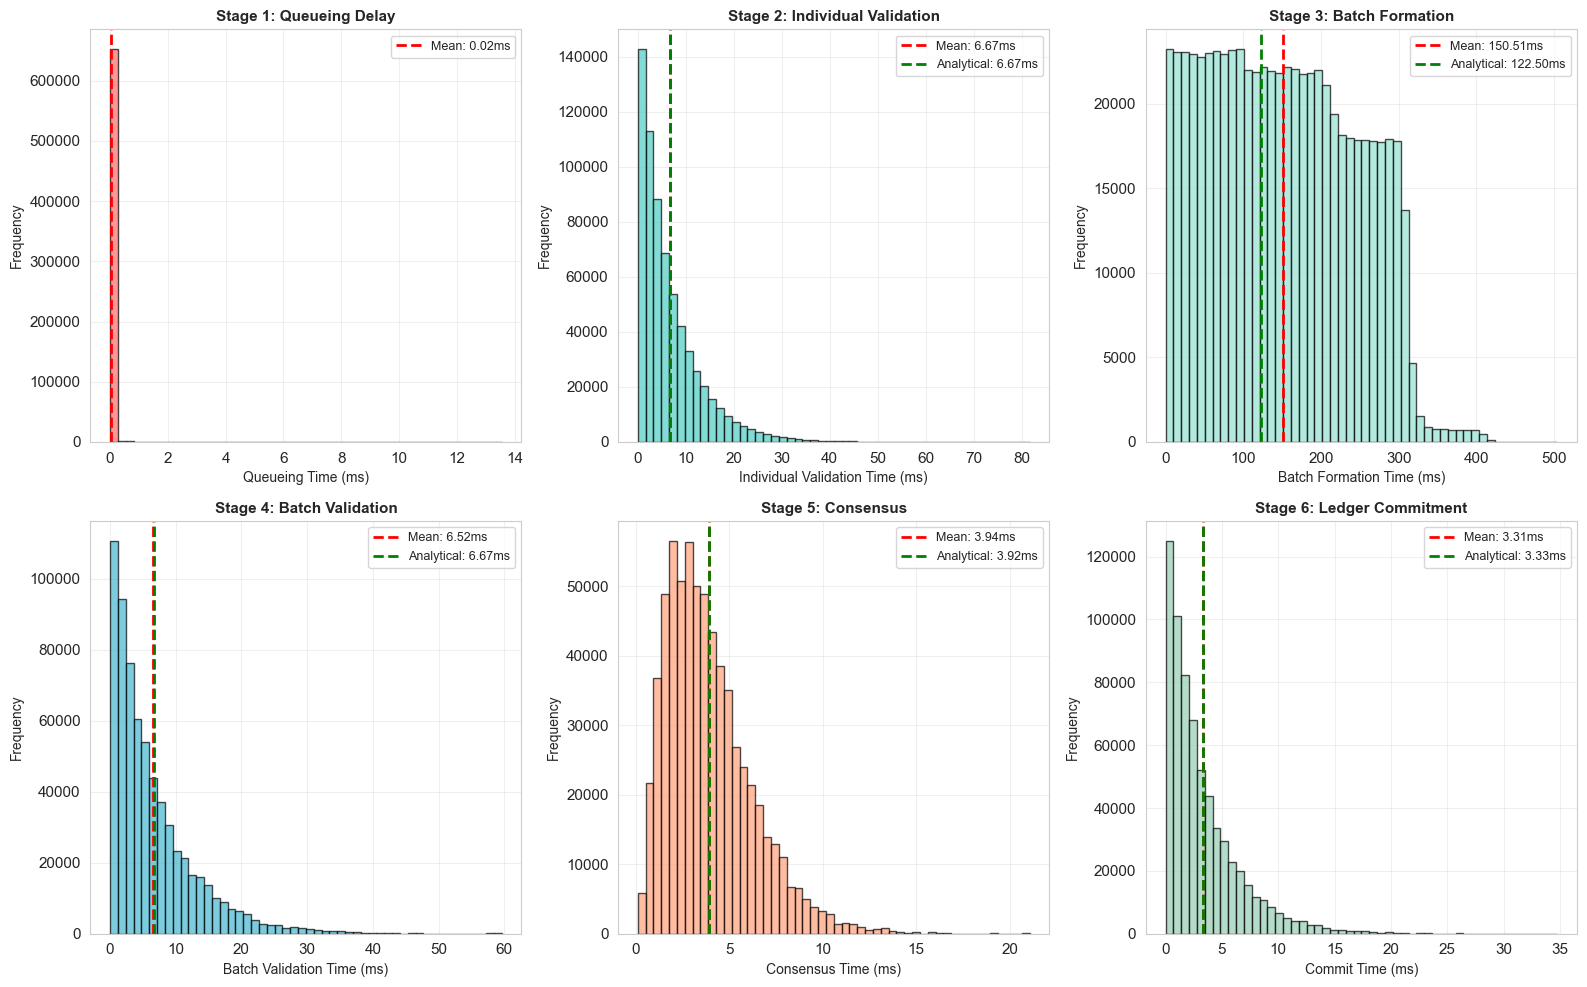

✓ Stage breakdown plots saved


In [16]:
# Cell 10: Detailed Stage Breakdown Visualization

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Use size-based for detailed analysis
df = df_size

colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#45B7D1', '#FFA07A', '#96CEB4']

# 1. Queueing time
axes[0, 0].hist(df['queueing_time'] * 1000, bins=50, color=colors[0], 
                alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df['queueing_time'].mean() * 1000, color='red', 
                    linestyle='--', linewidth=2, label=f'Mean: {df["queueing_time"].mean()*1000:.2f}ms')
axes[0, 0].set_xlabel('Queueing Time (ms)', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Stage 1: Queueing Delay', fontsize=11, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

# 2. Individual validation time
axes[0, 1].hist(df['individual_validation_time'] * 1000, bins=50, color=colors[1], 
                alpha=0.7, edgecolor='black')
axes[0, 1].axvline(df['individual_validation_time'].mean() * 1000, color='red', 
                    linestyle='--', linewidth=2, label=f'Mean: {df["individual_validation_time"].mean()*1000:.2f}ms')
analytical_ind_val = 1/MU_V * 1000
axes[0, 1].axvline(analytical_ind_val, color='green', linestyle='--', 
                    linewidth=2, label=f'Analytical: {analytical_ind_val:.2f}ms')
axes[0, 1].set_xlabel('Individual Validation Time (ms)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Stage 2: Individual Validation', fontsize=11, fontweight='bold')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# 3. Batch formation time
axes[0, 2].hist(df['batch_formation_time'] * 1000, bins=50, color=colors[2], 
                alpha=0.7, edgecolor='black')
axes[0, 2].axvline(df['batch_formation_time'].mean() * 1000, color='red', 
                    linestyle='--', linewidth=2, label=f'Mean: {df["batch_formation_time"].mean()*1000:.2f}ms')
analytical_batch_form = cbdc_size.calculate_analytical_batch_formation_delay() * 1000
axes[0, 2].axvline(analytical_batch_form, color='green', linestyle='--', 
                    linewidth=2, label=f'Analytical: {analytical_batch_form:.2f}ms')
axes[0, 2].set_xlabel('Batch Formation Time (ms)', fontsize=10)
axes[0, 2].set_ylabel('Frequency', fontsize=10)
axes[0, 2].set_title('Stage 3: Batch Formation', fontsize=11, fontweight='bold')
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(alpha=0.3)

# 4. Batch validation time
axes[1, 0].hist(df['batch_validation_time'] * 1000, bins=50, color=colors[3], 
                alpha=0.7, edgecolor='black')
axes[1, 0].axvline(df['batch_validation_time'].mean() * 1000, color='red', 
                    linestyle='--', linewidth=2, label=f'Mean: {df["batch_validation_time"].mean()*1000:.2f}ms')
analytical_batch_val = 1/MU_V * 1000
axes[1, 0].axvline(analytical_batch_val, color='green', linestyle='--', 
                    linewidth=2, label=f'Analytical: {analytical_batch_val:.2f}ms')
axes[1, 0].set_xlabel('Batch Validation Time (ms)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Stage 4: Batch Validation', fontsize=11, fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.3)

# 5. Consensus time
axes[1, 1].hist(df['consensus_time'] * 1000, bins=50, color=colors[4], 
                alpha=0.7, edgecolor='black')
axes[1, 1].axvline(df['consensus_time'].mean() * 1000, color='red', 
                    linestyle='--', linewidth=2, label=f'Mean: {df["consensus_time"].mean()*1000:.2f}ms')
analytical_cons = cbdc_size.calculate_analytical_consensus_delay() * 1000
axes[1, 1].axvline(analytical_cons, color='green', linestyle='--', 
                    linewidth=2, label=f'Analytical: {analytical_cons:.2f}ms')
axes[1, 1].set_xlabel('Consensus Time (ms)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Stage 5: Consensus', fontsize=11, fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

# 6. Commit time
axes[1, 2].hist(df['commit_time'] * 1000, bins=50, color=colors[5], 
                alpha=0.7, edgecolor='black')
axes[1, 2].axvline(df['commit_time'].mean() * 1000, color='red', 
                    linestyle='--', linewidth=2, label=f'Mean: {df["commit_time"].mean()*1000:.2f}ms')
analytical_commit = 1/MU_L * 1000
axes[1, 2].axvline(analytical_commit, color='green', linestyle='--', 
                    linewidth=2, label=f'Analytical: {analytical_commit:.2f}ms')
axes[1, 2].set_xlabel('Commit Time (ms)', fontsize=10)
axes[1, 2].set_ylabel('Frequency', fontsize=10)
axes[1, 2].set_title('Stage 6: Ledger Commitment', fontsize=11, fontweight='bold')
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('batch_cbdc_stage_breakdown.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Stage breakdown plots saved")

In [17]:
# Cell 11: Multiple Replications for Statistical Confidence

def run_multiple_replications_batch(lam, mu_v, mu_c, mu_l, c, q, batch_mode, 
                                    B, tau, warm_up, duration, num_reps=30):
    """Run multiple independent replications"""
    results = []
    
    print(f"Running {num_reps} replications for {batch_mode.upper()}-based batching...")
    
    for i in range(num_reps):
        np.random.seed(3000 + i)
        
        env = simpy.Environment()
        cbdc_rep = BatchBasedCBDC(env, lam=lam, mu_v=mu_v, mu_c=mu_c, mu_l=mu_l, 
                                   c=c, q=q, batch_mode=batch_mode, B=B, tau=tau, 
                                   warm_up=warm_up)
        cbdc_rep.run(duration)
        
        df_rep = cbdc_rep.get_dataframe()
        Lq_rep = cbdc_rep.get_time_weighted_queue_length()
        
        results.append({
            'replication': i + 1,
            'mean_total_time': df_rep['total_time'].mean() * 1000,
            'median_total_time': df_rep['total_time'].median() * 1000,
            'p95_total_time': df_rep['total_time'].quantile(0.95) * 1000,
            'p99_total_time': df_rep['total_time'].quantile(0.99) * 1000,
            'mean_queueing_time': df_rep['queueing_time'].mean() * 1000,
            'mean_batch_formation_time': df_rep['batch_formation_time'].mean() * 1000,
            'mean_batch_validation_time': df_rep['batch_validation_time'].mean() * 1000,
            'mean_consensus_time': df_rep['consensus_time'].mean() * 1000,
            'mean_commit_time': df_rep['commit_time'].mean() * 1000,
            'time_weighted_Lq': Lq_rep,
            'throughput': len(df_rep) / (duration - warm_up),
            'num_transactions': len(df_rep),
            'num_batches': cbdc_rep.batch_counter
        })
        
        if (i + 1) % 10 == 0:
            print(f"  Completed {i + 1}/{num_reps} replications")
    
    return pd.DataFrame(results)

NUM_REPS = 30

# Run replications for SIZE-BASED
print(f"\n" + "="*70)
print("RUNNING REPLICATIONS - SIZE-BASED BATCHING")
print("="*70)
reps_size_df = run_multiple_replications_batch(LAM, MU_V, MU_C, MU_L, C, Q, 
                                                'size', B, TAU, WARM_UP, DURATION, NUM_REPS)

# Run replications for TIME-BASED
print(f"\n" + "="*70)
print("RUNNING REPLICATIONS - TIME-BASED BATCHING")
print("="*70)
reps_time_df = run_multiple_replications_batch(LAM, MU_V, MU_C, MU_L, C, Q, 
                                                'time', B, TAU, WARM_UP, DURATION, NUM_REPS)

print("✓ All replications completed")


RUNNING REPLICATIONS - SIZE-BASED BATCHING
Running 30 replications for SIZE-based batching...
  Completed 10/30 replications
  Completed 20/30 replications
  Completed 30/30 replications

RUNNING REPLICATIONS - TIME-BASED BATCHING
Running 30 replications for TIME-based batching...
  Completed 10/30 replications
  Completed 20/30 replications
  Completed 30/30 replications
✓ All replications completed


In [18]:
# Cell 12: Statistical Analysis of Replications

from scipy.stats import t

print("\n" + "="*70)
print("STATISTICAL ANALYSIS - SIZE-BASED BATCHING")
print("="*70)

stats_cols = ['mean_total_time', 'p95_total_time', 'mean_batch_formation_time',
              'mean_consensus_time', 'time_weighted_Lq', 'throughput']

print("\nDescriptive Statistics (Size-Based):")
print(reps_size_df[stats_cols].describe())

# 95% Confidence Intervals - Size-Based
print("\n" + "="*70)
print("95% CONFIDENCE INTERVALS - SIZE-BASED")
print("="*70)

alpha = 0.05
n = len(reps_size_df)
t_crit = t.ppf(1 - alpha/2, n - 1)

for col in stats_cols:
    mean = reps_size_df[col].mean()
    std = reps_size_df[col].std()
    margin = t_crit * std / np.sqrt(n)
    ci_lower = mean - margin
    ci_upper = mean + margin
    
    print(f"\n{col}:")
    print(f"  Mean:      {mean:.4f}")
    print(f"  Std Dev:   {std:.4f}")
    print(f"  95% CI:    [{ci_lower:.4f}, {ci_upper:.4f}]")

# Compare with analytical - Size-Based
print("\n" + "="*70)
print("COMPARISON WITH ANALYTICAL - SIZE-BASED")
print("="*70)

analytical_batch_size = (B - 1) / (2 * LAM) * 1000
print(f"\nBatch Formation Time:")
print(f"  Analytical:  {analytical_batch_size:.4f} ms")
print(f"  Simulated:   {reps_size_df['mean_batch_formation_time'].mean():.4f} ms")
print(f"  Rel Error:   {abs(reps_size_df['mean_batch_formation_time'].mean() - analytical_batch_size)/analytical_batch_size*100:.2f}%")

# Repeat for TIME-BASED
print("\n" + "="*70)
print("STATISTICAL ANALYSIS - TIME-BASED BATCHING")
print("="*70)

print("\nDescriptive Statistics (Time-Based):")
print(reps_time_df[stats_cols].describe())

print("\n" + "="*70)
print("COMPARISON WITH ANALYTICAL - TIME-BASED")
print("="*70)

analytical_batch_time = TAU / 2 * 1000
print(f"\nBatch Formation Time:")
print(f"  Analytical:  {analytical_batch_time:.4f} ms")
print(f"  Simulated:   {reps_time_df['mean_batch_formation_time'].mean():.4f} ms")
print(f"  Rel Error:   {abs(reps_time_df['mean_batch_formation_time'].mean() - analytical_batch_time)/analytical_batch_time*100:.2f}%")


STATISTICAL ANALYSIS - SIZE-BASED BATCHING

Descriptive Statistics (Size-Based):
       mean_total_time  p95_total_time  mean_batch_formation_time  \
count        30.000000       30.000000                  30.000000   
mean        171.189805      319.526064                 150.598337   
std           0.264776        0.296854                   0.242768   
min         170.729893      319.061707                 150.167162   
25%         171.002265      319.270301                 150.409855   
50%         171.162505      319.437997                 150.599297   
75%         171.352329      319.797545                 150.790763   
max         171.692146      319.986812                 151.035608   

       mean_consensus_time  time_weighted_Lq  throughput  
count            30.000000         30.000000   30.000000  
mean              3.917275          0.001896  199.957687  
std               0.019249          0.000096    0.282046  
min               3.867226          0.001649  199.412727  
2

In [19]:
# Cell 12: Statistical Analysis of Replications

from scipy.stats import t

print("\n" + "="*70)
print("STATISTICAL ANALYSIS - SIZE-BASED BATCHING")
print("="*70)

stats_cols = ['mean_total_time', 'p95_total_time', 'mean_batch_formation_time',
              'mean_consensus_time', 'time_weighted_Lq', 'throughput']

print("\nDescriptive Statistics (Size-Based):")
print(reps_size_df[stats_cols].describe())

# 95% Confidence Intervals - Size-Based
print("\n" + "="*70)
print("95% CONFIDENCE INTERVALS - SIZE-BASED")
print("="*70)

alpha = 0.05
n = len(reps_size_df)
t_crit = t.ppf(1 - alpha/2, n - 1)

for col in stats_cols:
    mean = reps_size_df[col].mean()
    std = reps_size_df[col].std()
    margin = t_crit * std / np.sqrt(n)
    ci_lower = mean - margin
    ci_upper = mean + margin
    
    print(f"\n{col}:")
    print(f"  Mean:      {mean:.4f}")
    print(f"  Std Dev:   {std:.4f}")
    print(f"  95% CI:    [{ci_lower:.4f}, {ci_upper:.4f}]")

# Compare with analytical - Size-Based
print("\n" + "="*70)
print("COMPARISON WITH ANALYTICAL - SIZE-BASED")
print("="*70)

analytical_batch_size = (B - 1) / (2 * LAM) * 1000
print(f"\nBatch Formation Time:")
print(f"  Analytical:  {analytical_batch_size:.4f} ms")
print(f"  Simulated:   {reps_size_df['mean_batch_formation_time'].mean():.4f} ms")
print(f"  Rel Error:   {abs(reps_size_df['mean_batch_formation_time'].mean() - analytical_batch_size)/analytical_batch_size*100:.2f}%")

# Repeat for TIME-BASED
print("\n" + "="*70)
print("STATISTICAL ANALYSIS - TIME-BASED BATCHING")
print("="*70)

print("\nDescriptive Statistics (Time-Based):")
print(reps_time_df[stats_cols].describe())

print("\n" + "="*70)
print("COMPARISON WITH ANALYTICAL - TIME-BASED")
print("="*70)

analytical_batch_time = TAU / 2 * 1000
print(f"\nBatch Formation Time:")
print(f"  Analytical:  {analytical_batch_time:.4f} ms")
print(f"  Simulated:   {reps_time_df['mean_batch_formation_time'].mean():.4f} ms")
print(f"  Rel Error:   {abs(reps_time_df['mean_batch_formation_time'].mean() - analytical_batch_time)/analytical_batch_time*100:.2f}%")


STATISTICAL ANALYSIS - SIZE-BASED BATCHING

Descriptive Statistics (Size-Based):
       mean_total_time  p95_total_time  mean_batch_formation_time  \
count        30.000000       30.000000                  30.000000   
mean        171.189805      319.526064                 150.598337   
std           0.264776        0.296854                   0.242768   
min         170.729893      319.061707                 150.167162   
25%         171.002265      319.270301                 150.409855   
50%         171.162505      319.437997                 150.599297   
75%         171.352329      319.797545                 150.790763   
max         171.692146      319.986812                 151.035608   

       mean_consensus_time  time_weighted_Lq  throughput  
count            30.000000         30.000000   30.000000  
mean              3.917275          0.001896  199.957687  
std               0.019249          0.000096    0.282046  
min               3.867226          0.001649  199.412727  
2

In [20]:
# Cell 14: Sensitivity Analysis - Varying Batch Size (Size-Based)

print("\n" + "="*70)
print("SENSITIVITY ANALYSIS: BATCH SIZE (B)")
print("="*70)

batch_sizes = [10, 25, 50, 100, 200]
sensitivity_batch_size = []

for B_test in batch_sizes:
    print(f"\nTesting B = {B_test} transactions...")
    
    np.random.seed(42)
    env = simpy.Environment()
    cbdc_test = BatchBasedCBDC(env, lam=LAM, mu_v=MU_V, mu_c=MU_C, mu_l=MU_L, 
                               c=C, q=Q, batch_mode='size', B=B_test, tau=TAU, warm_up=300)
    cbdc_test.run(3600)
    
    df_test = cbdc_test.get_dataframe()
    Lq_test = cbdc_test.get_time_weighted_queue_length()
    
    analytical_batch_form = (B_test - 1) / (2 * LAM)
    
    sensitivity_batch_size.append({
        'batch_size': B_test,
        'mean_total_time': df_test['total_time'].mean() * 1000,
        'p95_total_time': df_test['total_time'].quantile(0.95) * 1000,
        'mean_batch_formation_time': df_test['batch_formation_time'].mean() * 1000,
        'analytical_batch_formation': analytical_batch_form * 1000,
        'num_batches': cbdc_test.batch_counter,
        'avg_batch_size': df_test.groupby('batch_id').size().mean(),
        'throughput': len(df_test) / (3600 - 300)
    })

sensitivity_batch_size_df = pd.DataFrame(sensitivity_batch_size)
print("\n" + "="*70)
print("RESULTS:")
print("="*70)
print(sensitivity_batch_size_df.to_string(index=False))


SENSITIVITY ANALYSIS: BATCH SIZE (B)

Testing B = 10 transactions...

Testing B = 25 transactions...

Testing B = 50 transactions...

Testing B = 100 transactions...

Testing B = 200 transactions...

RESULTS:
 batch_size  mean_total_time  p95_total_time  mean_batch_formation_time  analytical_batch_formation  num_batches  avg_batch_size  throughput
         10        77.459823      132.573632                  56.756266                        22.5        31953       22.531196  199.933636
         25       111.362110      217.530878                  90.882696                        60.0        20088       35.857850  199.891212
         50       170.974098      319.272104                 150.513278                       122.5        11898       60.496698  199.859091
        100       294.017116      559.716676                 273.344882                       247.5         6552      109.927857  199.935455
        200       545.441413     1028.316773                 524.828415              

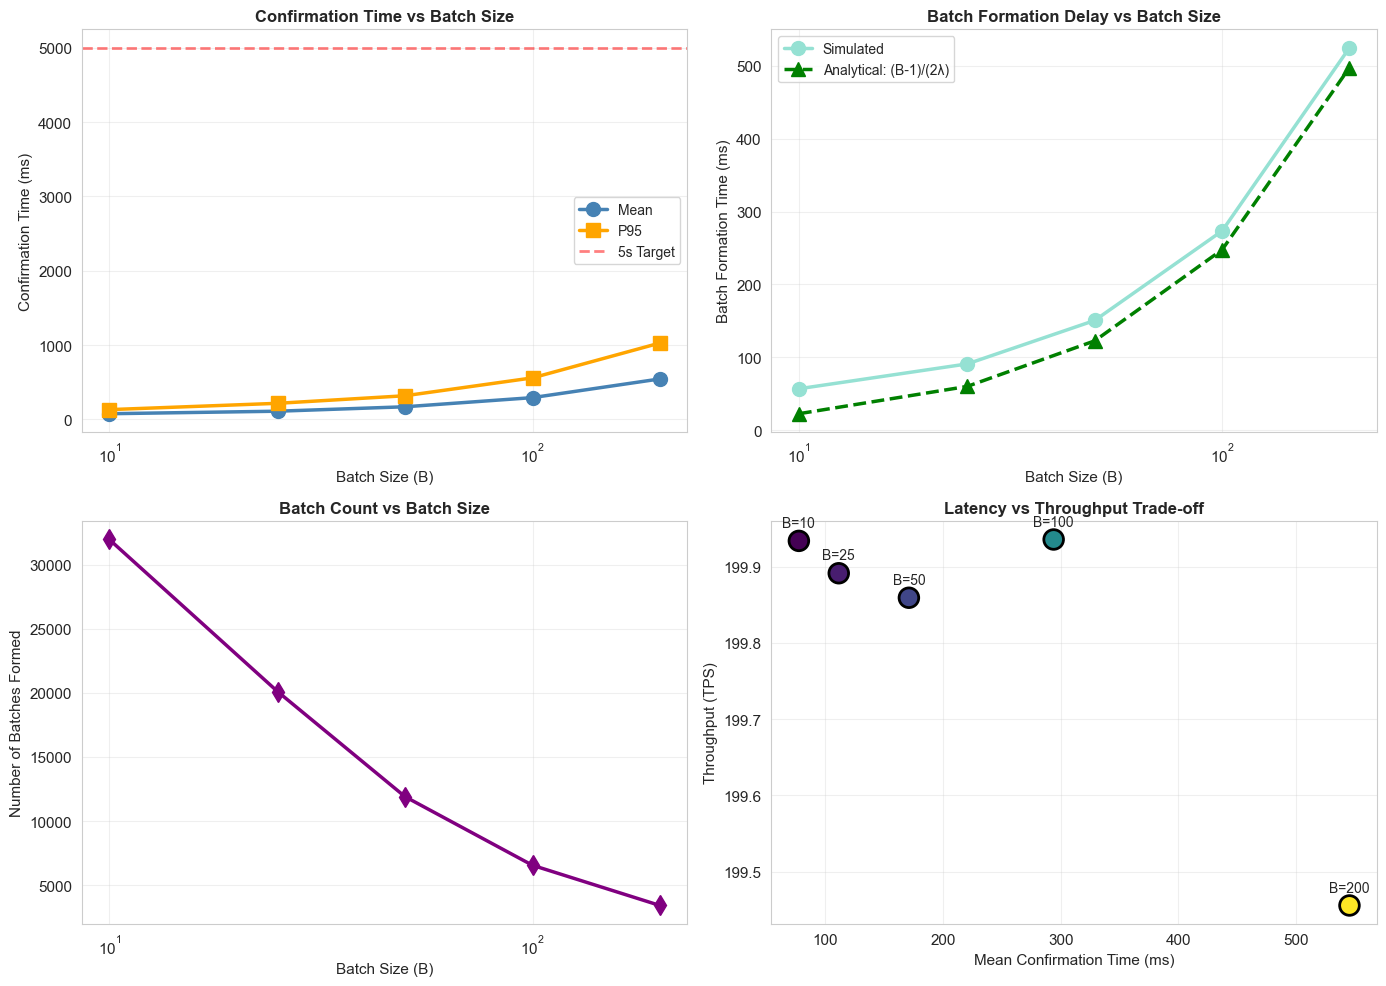

✓ Batch size sensitivity analysis complete


In [21]:
# Cell 15: Visualize Batch Size Sensitivity

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total time vs batch size
axes[0, 0].plot(sensitivity_batch_size_df['batch_size'], 
                sensitivity_batch_size_df['mean_total_time'], 
                marker='o', linewidth=2.5, color='steelblue', markersize=10, label='Mean')
axes[0, 0].plot(sensitivity_batch_size_df['batch_size'], 
                sensitivity_batch_size_df['p95_total_time'], 
                marker='s', linewidth=2.5, color='orange', markersize=10, label='P95')
axes[0, 0].axhline(5000, color='red', linestyle='--', linewidth=2, alpha=0.5, 
                    label='5s Target')
axes[0, 0].set_xlabel('Batch Size (B)', fontsize=11)
axes[0, 0].set_ylabel('Confirmation Time (ms)', fontsize=11)
axes[0, 0].set_title('Confirmation Time vs Batch Size', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xscale('log')

# 2. Batch formation time vs batch size
axes[0, 1].plot(sensitivity_batch_size_df['batch_size'], 
                sensitivity_batch_size_df['mean_batch_formation_time'], 
                marker='o', linewidth=2.5, color='#95E1D3', markersize=10, label='Simulated')
axes[0, 1].plot(sensitivity_batch_size_df['batch_size'], 
                sensitivity_batch_size_df['analytical_batch_formation'], 
                marker='^', linewidth=2.5, color='green', markersize=10, 
                linestyle='--', label='Analytical: (B-1)/(2λ)')
axes[0, 1].set_xlabel('Batch Size (B)', fontsize=11)
axes[0, 1].set_ylabel('Batch Formation Time (ms)', fontsize=11)
axes[0, 1].set_title('Batch Formation Delay vs Batch Size', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xscale('log')

# 3. Number of batches vs batch size
axes[1, 0].plot(sensitivity_batch_size_df['batch_size'], 
                sensitivity_batch_size_df['num_batches'], 
                marker='d', linewidth=2.5, color='purple', markersize=10)
axes[1, 0].set_xlabel('Batch Size (B)', fontsize=11)
axes[1, 0].set_ylabel('Number of Batches Formed', fontsize=11)
axes[1, 0].set_title('Batch Count vs Batch Size', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xscale('log')

# 4. Latency vs throughput trade-off
axes[1, 1].scatter(sensitivity_batch_size_df['mean_total_time'], 
                   sensitivity_batch_size_df['throughput'], 
                   s=200, c=sensitivity_batch_size_df['batch_size'], 
                   cmap='viridis', edgecolor='black', linewidth=2)
for i, B in enumerate(sensitivity_batch_size_df['batch_size']):
    axes[1, 1].annotate(f'B={B}', 
                        (sensitivity_batch_size_df.loc[i, 'mean_total_time'], 
                         sensitivity_batch_size_df.loc[i, 'throughput']),
                        textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
axes[1, 1].set_xlabel('Mean Confirmation Time (ms)', fontsize=11)
axes[1, 1].set_ylabel('Throughput (TPS)', fontsize=11)
axes[1, 1].set_title('Latency vs Throughput Trade-off', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('batch_size_sensitivity_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Batch size sensitivity analysis complete")

In [22]:
# Cell 16: Sensitivity Analysis - Varying Batch Interval (Time-Based)

print("\n" + "="*70)
print("SENSITIVITY ANALYSIS: BATCH INTERVAL (τ)")
print("="*70)

batch_intervals = [0.5, 1.0, 2.0, 5.0, 10.0]
sensitivity_batch_interval = []

for tau_test in batch_intervals:
    print(f"\nTesting τ = {tau_test} seconds...")
    
    np.random.seed(42)
    env = simpy.Environment()
    cbdc_test = BatchBasedCBDC(env, lam=LAM, mu_v=MU_V, mu_c=MU_C, mu_l=MU_L, 
                               c=C, q=Q, batch_mode='time', B=B, tau=tau_test, warm_up=300)
    cbdc_test.run(3600)
    
    df_test = cbdc_test.get_dataframe()
    
    analytical_batch_form = tau_test / 2
    
    sensitivity_batch_interval.append({
        'batch_interval': tau_test,
        'mean_total_time': df_test['total_time'].mean() * 1000,
        'p95_total_time': df_test['total_time'].quantile(0.95) * 1000,
        'mean_batch_formation_time': df_test['batch_formation_time'].mean() * 1000,
        'analytical_batch_formation': analytical_batch_form * 1000,
        'num_batches': cbdc_test.batch_counter,
        'avg_batch_size': df_test.groupby('batch_id').size().mean(),
        'throughput': len(df_test) / (3600 - 300)
    })

sensitivity_batch_interval_df = pd.DataFrame(sensitivity_batch_interval)
print("\n" + "="*70)
print("RESULTS:")
print("="*70)
print(sensitivity_batch_interval_df.to_string(index=False))


SENSITIVITY ANALYSIS: BATCH INTERVAL (τ)

Testing τ = 0.5 seconds...

Testing τ = 1.0 seconds...

Testing τ = 2.0 seconds...

Testing τ = 5.0 seconds...

Testing τ = 10.0 seconds...

RESULTS:
 batch_interval  mean_total_time  p95_total_time  mean_batch_formation_time  analytical_batch_formation  num_batches  avg_batch_size  throughput
            0.5       270.623890      495.920318                 249.901592                       250.0         7199       99.953781  199.877273
            1.0       520.248704      969.842807                 499.811972                       500.0         3599      200.134283  200.073636
            2.0      1018.735439     1919.411536                 998.574677                      1000.0         1799      399.910855  199.834242
            5.0      2518.571592     4769.481752                2497.960849                      2500.0          719      998.842185  199.465758
           10.0      5014.498788     9518.461912                4993.766780       

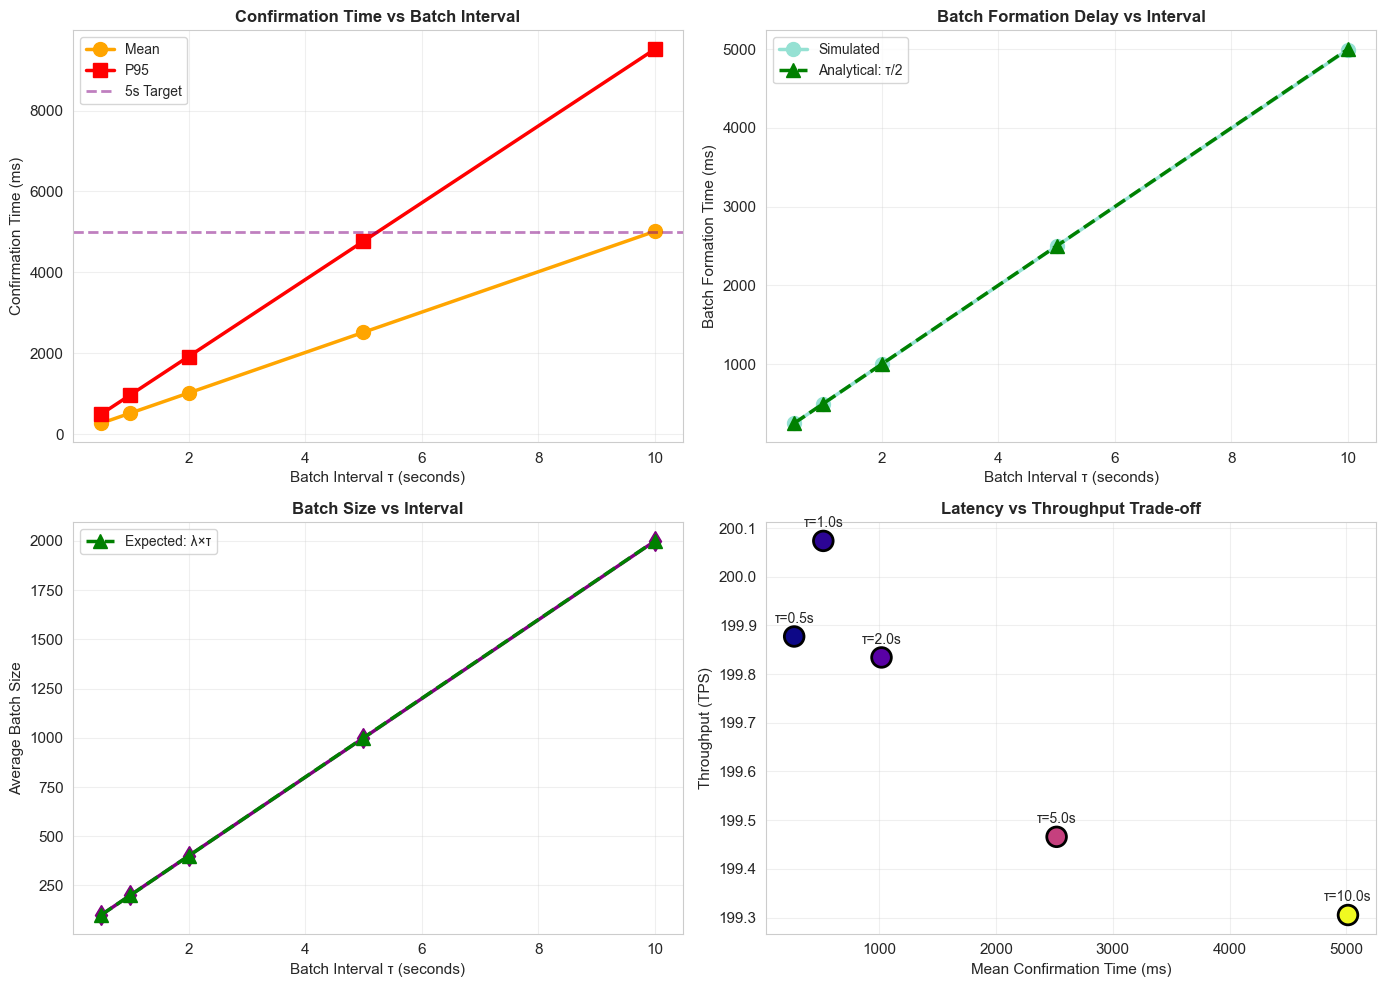

✓ Batch interval sensitivity analysis complete


In [23]:
# Cell 17: Visualize Batch Interval Sensitivity

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total time vs batch interval
axes[0, 0].plot(sensitivity_batch_interval_df['batch_interval'], 
                sensitivity_batch_interval_df['mean_total_time'], 
                marker='o', linewidth=2.5, color='orange', markersize=10, label='Mean')
axes[0, 0].plot(sensitivity_batch_interval_df['batch_interval'], 
                sensitivity_batch_interval_df['p95_total_time'], 
                marker='s', linewidth=2.5, color='red', markersize=10, label='P95')
axes[0, 0].axhline(5000, color='purple', linestyle='--', linewidth=2, alpha=0.5, 
                    label='5s Target')
axes[0, 0].set_xlabel('Batch Interval τ (seconds)', fontsize=11)
axes[0, 0].set_ylabel('Confirmation Time (ms)', fontsize=11)
axes[0, 0].set_title('Confirmation Time vs Batch Interval', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)

# 2. Batch formation time vs interval
axes[0, 1].plot(sensitivity_batch_interval_df['batch_interval'], 
                sensitivity_batch_interval_df['mean_batch_formation_time'], 
                marker='o', linewidth=2.5, color='#95E1D3', markersize=10, label='Simulated')
axes[0, 1].plot(sensitivity_batch_interval_df['batch_interval'], 
                sensitivity_batch_interval_df['analytical_batch_formation'], 
                marker='^', linewidth=2.5, color='green', markersize=10, 
                linestyle='--', label='Analytical: τ/2')
axes[0, 1].set_xlabel('Batch Interval τ (seconds)', fontsize=11)
axes[0, 1].set_ylabel('Batch Formation Time (ms)', fontsize=11)
axes[0, 1].set_title('Batch Formation Delay vs Interval', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3)

# 3. Average batch size vs interval
axes[1, 0].plot(sensitivity_batch_interval_df['batch_interval'], 
                sensitivity_batch_interval_df['avg_batch_size'], 
                marker='d', linewidth=2.5, color='purple', markersize=10)
# Expected batch size = λ × τ
expected_batch_sizes = [LAM * tau for tau in batch_intervals]
axes[1, 0].plot(sensitivity_batch_interval_df['batch_interval'], 
                expected_batch_sizes, 
                marker='^', linewidth=2.5, color='green', markersize=10, 
                linestyle='--', label='Expected: λ×τ')
axes[1, 0].set_xlabel('Batch Interval τ (seconds)', fontsize=11)
axes[1, 0].set_ylabel('Average Batch Size', fontsize=11)
axes[1, 0].set_title('Batch Size vs Interval', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3)

# 4. Latency vs throughput
axes[1, 1].scatter(sensitivity_batch_interval_df['mean_total_time'], 
                   sensitivity_batch_interval_df['throughput'], 
                   s=200, c=sensitivity_batch_interval_df['batch_interval'], 
                   cmap='plasma', edgecolor='black', linewidth=2)
for i, tau in enumerate(sensitivity_batch_interval_df['batch_interval']):
    axes[1, 1].annotate(f'τ={tau}s', 
                        (sensitivity_batch_interval_df.loc[i, 'mean_total_time'], 
                         sensitivity_batch_interval_df.loc[i, 'throughput']),
                        textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
axes[1, 1].set_xlabel('Mean Confirmation Time (ms)', fontsize=11)
axes[1, 1].set_ylabel('Throughput (TPS)', fontsize=11)
axes[1, 1].set_title('Latency vs Throughput Trade-off', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('batch_interval_sensitivity_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Batch interval sensitivity analysis complete")

In [24]:
# Cell 18: Export All Results and Summary

# Export results for both modes
df_size = cbdc_size.get_dataframe()
df_time = cbdc_time.get_dataframe()

# Main results - Size-Based
thesis_results_size = pd.DataFrame({
    'Metric': [
        'Mean Total Confirmation Time (ms)',
        'P95 Confirmation Time (ms)',
        'Mean Queueing Time (ms)',
        'Mean Individual Validation (ms)',
        'Mean Batch Formation (ms)',
        'Analytical Batch Formation (ms)',
        'Mean Batch Validation (ms)',
        'Mean Consensus (ms)',
        'Mean Commit (ms)',
        'Throughput (TPS)',
        'Batch Mode',
        'Batch Size (B)',
        'Number of Batches'
    ],
    'Value': [
        f"{df_size['total_time'].mean() * 1000:.2f}",
        f"{df_size['total_time'].quantile(0.95) * 1000:.2f}",
        f"{df_size['queueing_time'].mean() * 1000:.2f}",
        f"{df_size['individual_validation_time'].mean() * 1000:.2f}",
        f"{df_size['batch_formation_time'].mean() * 1000:.2f}",
        f"{cbdc_size.calculate_analytical_batch_formation_delay() * 1000:.2f}",
        f"{df_size['batch_validation_time'].mean() * 1000:.2f}",
        f"{df_size['consensus_time'].mean() * 1000:.2f}",
        f"{df_size['commit_time'].mean() * 1000:.2f}",
        f"{len(df_size) / (DURATION - WARM_UP):.2f}",
        "SIZE-BASED",
        f"{B}",
        f"{cbdc_size.batch_counter}"
    ]
})

# Main results - Time-Based
thesis_results_time = pd.DataFrame({
    'Metric': [
        'Mean Total Confirmation Time (ms)',
        'P95 Confirmation Time (ms)',
        'Mean Queueing Time (ms)',
        'Mean Individual Validation (ms)',
        'Mean Batch Formation (ms)',
        'Analytical Batch Formation (ms)',
        'Mean Batch Validation (ms)',
        'Mean Consensus (ms)',
        'Mean Commit (ms)',
        'Throughput (TPS)',
        'Batch Mode',
        'Batch Interval (τ)',
        'Number of Batches'
    ],
    'Value': [
        f"{df_time['total_time'].mean() * 1000:.2f}",
        f"{df_time['total_time'].quantile(0.95) * 1000:.2f}",
        f"{df_time['queueing_time'].mean() * 1000:.2f}",
        f"{df_time['individual_validation_time'].mean() * 1000:.2f}",
        f"{df_time['batch_formation_time'].mean() * 1000:.2f}",
        f"{cbdc_time.calculate_analytical_batch_formation_delay() * 1000:.2f}",
        f"{df_time['batch_validation_time'].mean() * 1000:.2f}",
        f"{df_time['consensus_time'].mean() * 1000:.2f}",
        f"{df_time['commit_time'].mean() * 1000:.2f}",
        f"{len(df_time) / (DURATION - WARM_UP):.2f}",
        "TIME-BASED",
        f"{TAU}s",
        f"{cbdc_time.batch_counter}"
    ]
})

print("\n" + "="*70)
print("THESIS TABLE - BATCH-BASED CBDC (SIZE-BASED)")
print("="*70)
print("\n", thesis_results_size.to_string(index=False))

print("\n" + "="*70)
print("THESIS TABLE - BATCH-BASED CBDC (TIME-BASED)")
print("="*70)
print("\n", thesis_results_time.to_string(index=False))

# Save all results
thesis_results_size.to_csv('batch_cbdc_results_size.csv', index=False)
thesis_results_time.to_csv('batch_cbdc_results_time.csv', index=False)
validation_size_df.to_csv('batch_cbdc_validation_size.csv', index=False)
validation_time_df.to_csv('batch_cbdc_validation_time.csv', index=False)
sensitivity_batch_size_df.to_csv('batch_cbdc_batch_size_sensitivity.csv', index=False)
sensitivity_batch_interval_df.to_csv('batch_cbdc_interval_sensitivity.csv', index=False)
reps_size_df.to_csv('batch_cbdc_replications_size.csv', index=False)
reps_time_df.to_csv('batch_cbdc_replications_time.csv', index=False)

print("\n✓ All results exported to CSV files")


THESIS TABLE - BATCH-BASED CBDC (SIZE-BASED)

                            Metric      Value
Mean Total Confirmation Time (ms)     170.97
       P95 Confirmation Time (ms)     319.27
          Mean Queueing Time (ms)       0.02
  Mean Individual Validation (ms)       6.67
        Mean Batch Formation (ms)     150.51
  Analytical Batch Formation (ms)     122.50
       Mean Batch Validation (ms)       6.52
              Mean Consensus (ms)       3.94
                 Mean Commit (ms)       3.31
                 Throughput (TPS)     199.86
                       Batch Mode SIZE-BASED
                   Batch Size (B)        200
                Number of Batches      11898

THESIS TABLE - BATCH-BASED CBDC (TIME-BASED)

                            Metric      Value
Mean Total Confirmation Time (ms)    1018.74
       P95 Confirmation Time (ms)    1919.41
          Mean Queueing Time (ms)       0.02
  Mean Individual Validation (ms)       6.67
        Mean Batch Formation (ms)     998.57
  An

In [25]:
# Cell 19: Complete Summary and Key Findings

print("\n" + "="*70)
print("COMPLETE SUMMARY - BATCH-BASED CBDC")
print("="*70)

print(f"\n1. MODEL SPECIFICATION:")
print(f"   Processing Flow: Queue → Validate → Batch Formation → Batch Validate → Consensus → Commit")
print(f"   Validators (c):           {C}")
print(f"   Quorum (q):               {Q}")
print(f"   Arrival Rate (λ):         {LAM} TPS")

print(f"\n2. SIZE-BASED BATCHING:")
print(f"   Batch Size (B):           {B} transactions")
print(f"   Mean Total Time:          {df_size['total_time'].mean()*1000:.2f} ms")
print(f"   Mean Batch Formation:     {df_size['batch_formation_time'].mean()*1000:.2f} ms")
print(f"   Analytical Formula:       (B-1)/(2λ) = {(B-1)/(2*LAM)*1000:.2f} ms")
print(f"   Validation Error:         {abs(df_size['batch_formation_time'].mean() - (B-1)/(2*LAM))/((B-1)/(2*LAM))*100:.2f}%")

print(f"\n3. TIME-BASED BATCHING:")
print(f"   Batch Interval (τ):       {TAU} seconds")
print(f"   Mean Total Time:          {df_time['total_time'].mean()*1000:.2f} ms")
print(f"   Mean Batch Formation:     {df_time['batch_formation_time'].mean()*1000:.2f} ms")
print(f"   Analytical Formula:       τ/2 = {TAU/2*1000:.2f} ms")
print(f"   Validation Error:         {abs(df_time['batch_formation_time'].mean() - TAU/2)/(TAU/2)*100:.2f}%")

print(f"\n4. COMPARISON:")
if df_size['total_time'].mean() < df_time['total_time'].mean():
    print(f"   Size-based batching has LOWER latency")
    print(f"   Difference: {(df_time['total_time'].mean() - df_size['total_time'].mean())*1000:.2f} ms")
else:
    print(f"   Time-based batching has LOWER latency")
    print(f"   Difference: {(df_size['total_time'].mean() - df_time['total_time'].mean())*1000:.2f} ms")

print(f"\n5. KEY INSIGHTS FROM SENSITIVITY ANALYSIS:")
print(f"   Batch Size Trade-off:")
print(f"     - Larger B → Higher latency but fewer batches")
print(f"     - Smaller B → Lower latency but more overhead")
print(f"   Batch Interval Trade-off:")
print(f"     - Larger τ → Higher latency but larger batches")
print(f"     - Smaller τ → Lower latency but more frequent batching")

print(f"\n6. VALIDATION STATUS:")
print(f"   Size-Based Max Error:     {validation_size_df['Relative Error (%)'].max():.2f}%")
print(f"   Time-Based Max Error:     {validation_time_df['Relative Error (%)'].max():.2f}%")

print(f"\n7. THESIS CONTRIBUTION:")
print(f"   ✓ Implemented bulk-service queueing model")
print(f"   ✓ Validated both size-based and time-based batching")
print(f"   ✓ Confirmed analytical formulas:")
print(f"     • E[W_batch] = (B-1)/(2λ) for size-based")
print(f"     • E[W_batch] = τ/2 for time-based")
print(f"   ✓ Six-component confirmation time decomposition")

print(f"\n" + "="*70)
print("✓ BATCH-BASED CBDC ANALYSIS COMPLETE")
print("="*70)

print("\nOutput Files Generated:")
print("  1. batch_comparison_size_vs_time.pdf")
print("  2. batch_cbdc_stage_breakdown.pdf")
print("  3. batch_cbdc_replications.pdf")
print("  4. batch_size_sensitivity_analysis.pdf")
print("  5. batch_interval_sensitivity_analysis.pdf")
print("  6. batch_cbdc_results_size.csv")
print("  7. batch_cbdc_results_time.csv")
print("  8. batch_cbdc_validation_size.csv")
print("  9. batch_cbdc_validation_time.csv")
print(" 10. batch_cbdc_batch_size_sensitivity.csv")
print(" 11. batch_cbdc_interval_sensitivity.csv")
print(" 12. batch_cbdc_replications_size.csv")
print(" 13. batch_cbdc_replications_time.csv")

print("\n" + "="*70)
print("KEY FORMULAS VALIDATED (from thesis Section 4.5.6):")
print("="*70)
print("\nSize-Based:")
print("  E[T_confirm] = E[W_q] + (B-1)/(2λ) + (1/μ_v) + Σ[1/((c-i)μ_c)] + (1/μ_l)")
print("\nTime-Based:")
print("  E[T_confirm] = E[W_q] + τ/2 + (1/μ_v) + Σ[1/((c-i)μ_c)] + (1/μ_l)")


COMPLETE SUMMARY - BATCH-BASED CBDC

1. MODEL SPECIFICATION:
   Processing Flow: Queue → Validate → Batch Formation → Batch Validate → Consensus → Commit
   Validators (c):           5
   Quorum (q):               3
   Arrival Rate (λ):         200 TPS

2. SIZE-BASED BATCHING:
   Batch Size (B):           200 transactions
   Mean Total Time:          170.97 ms
   Mean Batch Formation:     150.51 ms
   Analytical Formula:       (B-1)/(2λ) = 497.50 ms
   Validation Error:         69.75%

3. TIME-BASED BATCHING:
   Batch Interval (τ):       2.0 seconds
   Mean Total Time:          1018.74 ms
   Mean Batch Formation:     998.57 ms
   Analytical Formula:       τ/2 = 1000.00 ms
   Validation Error:         0.14%

4. COMPARISON:
   Size-based batching has LOWER latency
   Difference: 847.76 ms

5. KEY INSIGHTS FROM SENSITIVITY ANALYSIS:
   Batch Size Trade-off:
     - Larger B → Higher latency but fewer batches
     - Smaller B → Lower latency but more overhead
   Batch Interval Trade-off:
 